In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import kagglehub



In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
dataset_path = Path(
    kagglehub.dataset_download(
        "aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented"
    )
)

image_root = dataset_path / "combined_images"

print("Dataset path:", dataset_path)
print("Image folder:", image_root)
print("Image folder exists:", image_root.exists())

Dataset path: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
Image folder: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images
Image folder exists: True


In [4]:
class_counts = {}

for class_folder in sorted(image_root.iterdir()):
    if class_folder.is_dir():
        image_count = sum(
            file.suffix.lower() in {
                ".jpg", ".jpeg", ".png"
            }
            for file in class_folder.iterdir()
        )

        class_counts[class_folder.name] = image_count

class_counts_df = pd.DataFrame(
    class_counts.items(),
    columns=["Class", "Image Count"]
)

display(class_counts_df)
print("Total images:", class_counts_df["Image Count"].sum())

,Class,Image Count
0,MildDemented,10000
1,ModerateDemented,10000
2,NonDemented,12800
3,VeryMildDemented,11200


Total images: 44000


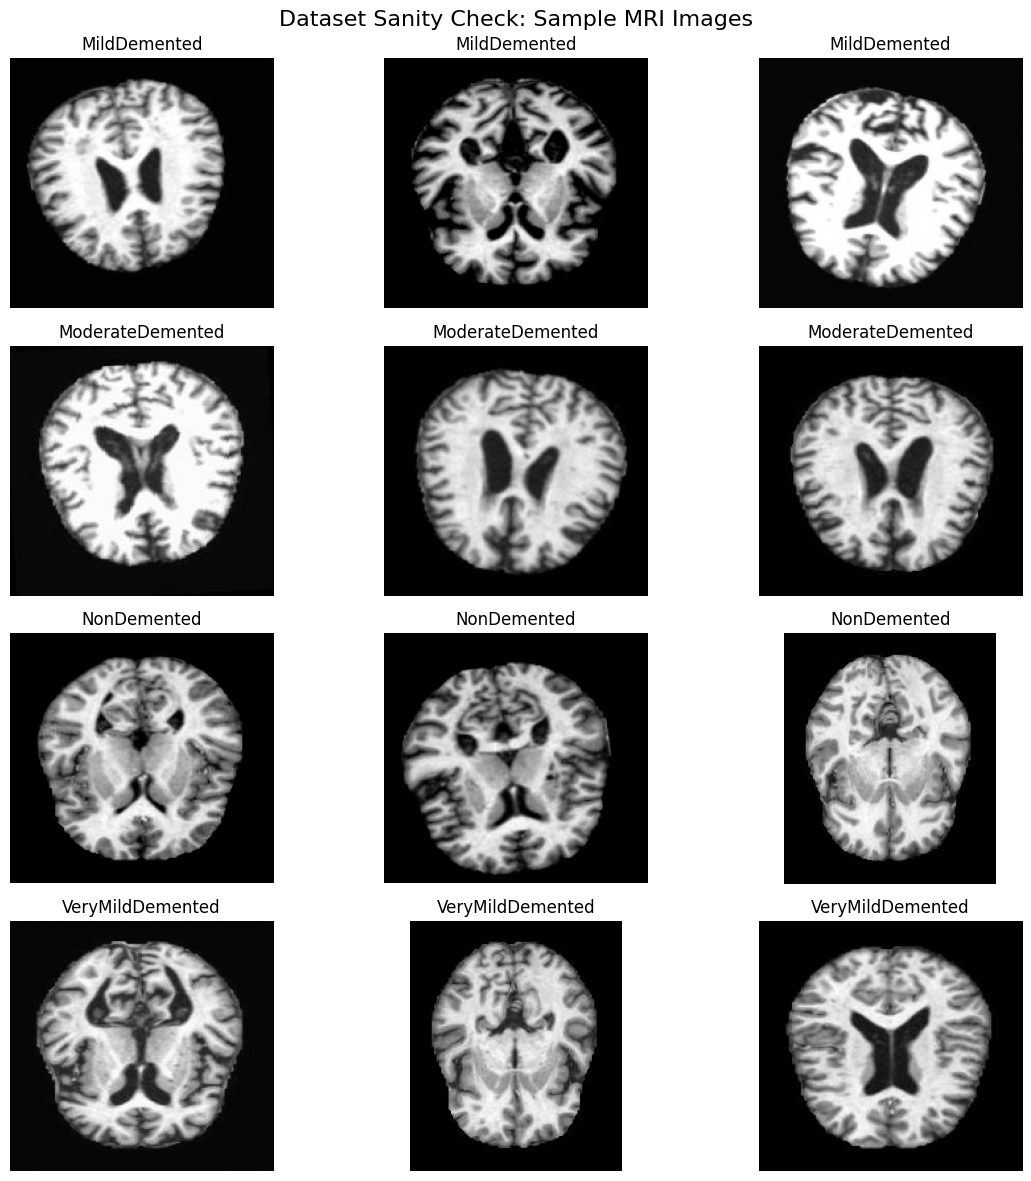

In [5]:
class_names = sorted(class_counts.keys())
rng = np.random.default_rng(SEED)

plt.figure(figsize=(12, 12))

for row, class_name in enumerate(class_names):
    class_folder = image_root / class_name

    image_paths = [
        file for file in class_folder.iterdir()
        if file.suffix.lower() in {
            ".jpg", ".jpeg", ".png"
        }
    ]

    selected_images = rng.choice(
        image_paths,
        size=3,
        replace=False
    )

    for column, image_path in enumerate(selected_images):
        image = tf.keras.utils.load_img(
            image_path,
            color_mode="grayscale"
        )

        plot_number = row * 3 + column + 1

        plt.subplot(
            len(class_names),
            3,
            plot_number
        )

        plt.imshow(
            image,
            cmap="gray"
        )

        plt.title(class_name)
        plt.axis("off")

plt.suptitle(
    "Dataset Sanity Check: Sample MRI Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [6]:
class_to_binary = {
    "NonDemented": 0,
    "VeryMildDemented": 1,
    "MildDemented": 1,
    "ModerateDemented": 1
}

records = []

for class_name, binary_label in class_to_binary.items():
    class_folder = image_root / class_name

    for image_path in sorted(class_folder.iterdir()):
        if image_path.suffix.lower() in {
            ".jpg", ".jpeg", ".png"
        }:
            records.append({
                "filepath": str(image_path),
                "original_class": class_name,
                "label": binary_label
            })

df = pd.DataFrame(records)

print("Total indexed images:", len(df))
print(df["label"].value_counts().sort_index())

Total indexed images: 44000
label
0    12800
1    31200
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

development_df, test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["label"],
    random_state=SEED
)

train_df, validation_df = train_test_split(
    development_df,
    test_size=15 / 85,
    stratify=development_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

for name, split_df in [
    ("Training", train_df),
    ("Validation", validation_df),
    ("Testing", test_df)
]:
    print(f"\n{name}: {len(split_df)} images")
    print(split_df["label"].value_counts().sort_index())


Training: 30800 images
label
0     8960
1    21840
Name: count, dtype: int64

Validation: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64

Testing: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64


In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_resize_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)

    return image, label


def create_dataset(dataframe, training=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["filepath"].values,
            dataframe["label"].values
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=min(len(dataframe), 10000),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_and_resize_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_dataset = create_dataset(
    train_df,
    training=True
)

validation_dataset = create_dataset(
    validation_df
)

test_dataset = create_dataset(
    test_df
)

for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print(
        "Pixel range:",
        float(tf.reduce_min(images)),
        "to",
        float(tf.reduce_max(images))
    )

I0000 00:00:1787566472.492057      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 to 255.0


In [9]:
from sklearn.utils.class_weight import compute_class_weight

MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 0.0001

weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"]
)

class_weights = {
    0: float(weight_values[0]),
    1: float(weight_values[1])
}

print("Maximum epochs:", MAX_EPOCHS)
print("Patience:", PATIENCE)
print("Learning rate:", LEARNING_RATE)
print("Batch size:", BATCH_SIZE)
print("Class weights:", class_weights)

Maximum epochs: 30
Patience: 5
Learning rate: 0.0001
Batch size: 32
Class weights: {0: 1.71875, 1: 0.7051282051282052}


In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05)
])

densenet_base = tf.keras.applications.DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

densenet_base.trainable = False

inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

x = data_augmentation(inputs)

x = tf.keras.applications.densenet.preprocess_input(
    x
)

x = densenet_base(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.30)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(
    inputs,
    outputs,
    name="DenseNet121_Binary"
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Total parameters:", model.count_params())

print(
    "Trainable parameters:",
    sum(
        tf.keras.backend.count_params(weight)
        for weight in model.trainable_weights
    )
)

print(
    "DenseNet121 frozen:",
    not densenet_base.trainable
)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameters: 7038529
Trainable parameters: 1025
DenseNet121 frozen: True


Model: "DenseNet121_Binary"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [11]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/densenet121_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=MAX_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.5477 - loss: 0.7517
Epoch 1: val_loss improved from None to 0.61416, saving model to /kaggle/working/densenet121_best.keras

Epoch 1: finished saving model to /kaggle/working/densenet121_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 163s 153ms/step - accuracy: 0.5798 - loss: 0.7142 - val_accuracy: 0.6727 - val_loss: 0.6142 - learning_rate: 1.0000e-04
Epoch 2/30
962/963 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6459 - loss: 0.6396
Epoch 2: val_loss improved from 0.61416 to 0.58278, saving model to /kaggle/working/densenet121_best.keras

Epoch 2: finished saving model to /kaggle/working/densenet121_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 100s 104ms/step - accuracy: 0.6603 - loss: 0.6253 - val_accuracy: 0.7077 - val_loss: 0.5828 - learning_rate: 1.0000e-04
Epoch 3/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.6870 - loss: 0.5945
Epoch 3: val_loss did not improve from 0.58278
963/963 ━━━━━━━━━━━━━━━━━━━━ 100s 

In [12]:
history_df = pd.DataFrame(
    history.history
)

history_df.index = range(
    1,
    len(history_df) + 1
)

history_df.index.name = "Epoch"

best_epoch = history_df[
    "val_loss"
].idxmin()

display(
    history_df[
        [
            "loss",
            "accuracy",
            "val_loss",
            "val_accuracy"
        ]
    ].rename(
        columns={
            "loss": "Training Loss",
            "accuracy": "Training Accuracy",
            "val_loss": "Validation Loss",
            "val_accuracy": "Validation Accuracy"
        }
    ).round(4)
)

print("Best epoch:", best_epoch)

,Training Loss,Training Accuracy,Validation Loss,Validation Accuracy
Epoch,,,,
1,0.7142,0.5798,0.6142,0.6727
2,0.6253,0.6603,0.5828,0.7077
3,0.5839,0.6959,0.5862,0.7000
4,0.5641,0.7176,0.6346,0.6589
5,0.5506,0.7250,0.5864,0.6991
6,0.5462,0.7283,0.5705,0.7088
7,0.5405,0.7341,0.5882,0.6962
8,0.5384,0.7329,0.5791,0.7017
9,0.5324,0.7386,0.5732,0.7067


Best epoch: 6


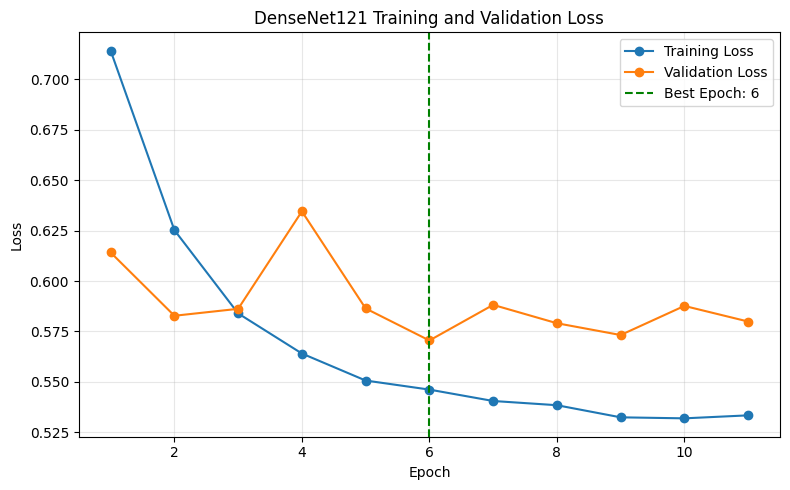

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df.index,
    history_df["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_df.index,
    history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    color="green",
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)

plt.title("DenseNet121 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

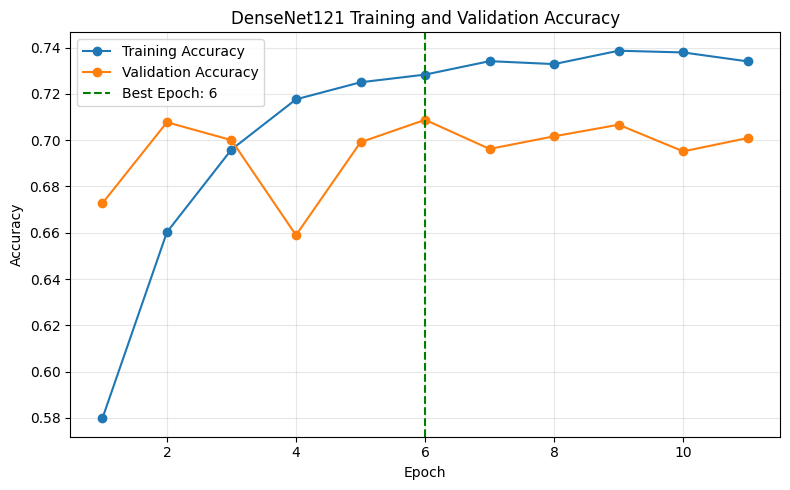

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df.index,
    history_df["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history_df.index,
    history_df["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    best_epoch,
    color="green",
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)

plt.title("DenseNet121 Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
test_loss, test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

207/207 ━━━━━━━━━━━━━━━━━━━━ 21s 103ms/step - accuracy: 0.7214 - loss: 0.5596
Test Loss: 0.5596
Test Accuracy: 0.7214


In [16]:
test_probabilities = model.predict(
    test_dataset,
    verbose=1
).ravel()

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

true_labels = test_df[
    "label"
].to_numpy()

print("Test images:", len(true_labels))
print("Predictions:", len(test_predictions))

207/207 ━━━━━━━━━━━━━━━━━━━━ 24s 98ms/step
Test images: 6600
Predictions: 6600


In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Test Loss:", round(test_loss, 4))

print("Accuracy:", round(
    accuracy_score(
        true_labels,
        test_predictions
    ), 4
))

print("Precision:", round(
    precision_score(
        true_labels,
        test_predictions
    ), 4
))

print("Recall:", round(
    recall_score(
        true_labels,
        test_predictions
    ), 4
))

print("F1-score:", round(
    f1_score(
        true_labels,
        test_predictions
    ), 4
))

print("ROC-AUC:", round(
    roc_auc_score(
        true_labels,
        test_probabilities
    ), 4
))

Test Loss: 0.5596
Accuracy: 0.7214
Precision: 0.9032
Recall: 0.6799
F1-score: 0.7758
ROC-AUC: 0.8415


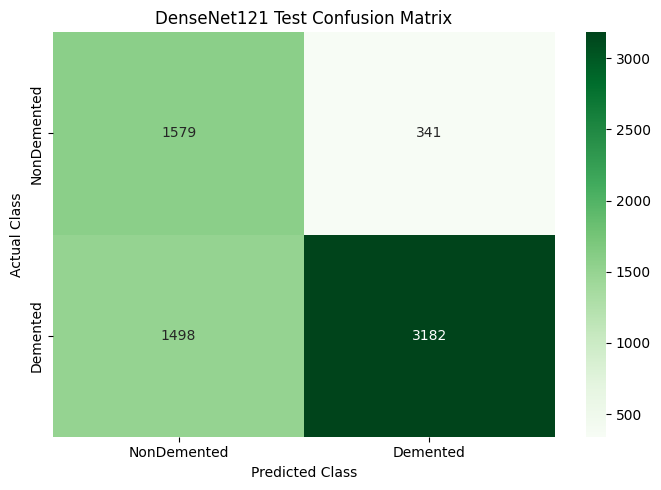

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    true_labels,
    test_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=[
        "NonDemented",
        "Demented"
    ],
    yticklabels=[
        "NonDemented",
        "Demented"
    ]
)

plt.title(
    "DenseNet121 Test Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

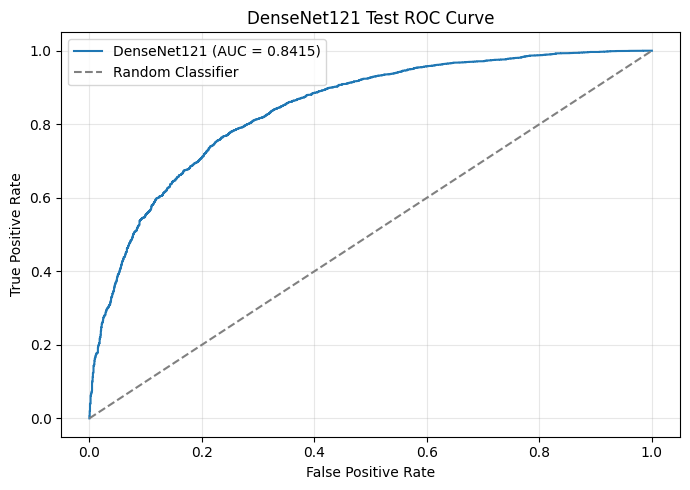

In [19]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    true_labels,
    test_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"DenseNet121 (AUC = {0.8415:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.title("DenseNet121 Test ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()